## Forward and inverse solutions for source reconstruction

This notebook sets up the source reconstruction pipeline:

1. **[Noise Covariance](https://mne.tools/stable/generated/mne.compute_raw_covariance.html)**: Compute from empty room recording to characterize sensor noise
2. **[Source Space](https://mne.tools/stable/generated/mne.setup_source_space.html)**: Define cortical locations where brain activity will be estimated
3. **[BEM Model](https://mne.tools/stable/generated/mne.make_bem_model.html)**: Create head model (boundary element method) for forward modeling
4. **[Forward Solution](https://mne.tools/stable/generated/mne.make_forward_solution.html)**: Compute how activity at each source projects to sensors
5. **[Inverse Operator](https://mne.tools/stable/generated/mne.minimum_norm.make_inverse_operator.html)**: Combine forward solution + noise covariance for source estimation

**Prerequisites:**
- Maxwell filtered + ICA cleaned subject data
- Maxwell filtered empty room recording (for noise covariance)
- FreeSurfer reconstruction completed
- MEG-MRI coregistration (trans file) from GUI

In [1]:
# load packages
import os
import time
import numpy as np
import mne
from mne.io import read_raw_fif
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

In [2]:
# session info
subject = 'nbl_006'
session = '01'
processed_meg_dir = '/mnt/sphere/nbl/processed_meg/'
processed_mri_dir = '/mnt/sphere/nbl/processed_mri/'

# MEG files
raw_fname = os.path.join(processed_meg_dir, subject, 'ses-'+session, f"{subject}_ALL_post_ica-raw.fif")
er_fname = os.path.join(processed_meg_dir, subject, 'ses-'+session, f"{subject}_emptyroom_sss_raw.fif")

# static anatomical files
src_fname = os.path.join(processed_mri_dir, subject, 'bem', f"{subject}-src.fif")
bem_fname = os.path.join(processed_mri_dir, subject, 'bem', f"{subject}-inner_skull-bem-sol.fif")

# session-specific files
cov_fname = os.path.join(processed_mri_dir, subject, 'bem', 'ses-'+session, f"{subject}_ses-{session}-cov.fif")
trans_fname = os.path.join(processed_mri_dir, subject, 'bem', 'ses-'+session, f"{subject}_ses-{session}-trans.fif")
fwd_fname = os.path.join(processed_mri_dir, subject, 'bem', 'ses-'+session, f"{subject}_ses-{session}-fwd.fif")
inv_fname = os.path.join(processed_mri_dir, subject, 'bem', 'ses-'+session, f"{subject}_ses-{session}-inv.fif")

In [3]:
# load data
print (f"Reading raw files for {subject}...")
t = time.time()
raw = read_raw_fif(raw_fname, preload=True, verbose=False)
raw_emptyroom = read_raw_fif(er_fname, preload=True, verbose=False)
elapsed_readraw = time.time() - t
print(f"Loaded in {elapsed_readraw:.1f} seconds.\n")

Reading raw files for nbl_006...
Loaded in 131.0 seconds.



#### Make source reconstruction

In [4]:
# noise covariance
noise_cov = mne.compute_raw_covariance(raw_emptyroom, rank='info', verbose=True)
mne.write_cov(cov_fname, noise_cov, overwrite=True, verbose=True)

# source space
src = mne.setup_source_space(subject, spacing='oct6', subjects_dir=processed_mri_dir, add_dist=False, verbose=True)
mne.write_source_spaces(src_fname, src, overwrite=True, verbose=True)

# bem
model = mne.make_bem_model(subject=subject, conductivity=[0.3],  # single layer for MEG
                           subjects_dir=processed_mri_dir, verbose=True)
bem = mne.make_bem_solution(model)
mne.write_bem_solution(bem_fname, bem, overwrite=True, verbose=True)

# trans file (from GUI coregistration)
trans = mne.read_trans(trans_fname)

# forward solution
fwd = mne.make_forward_solution(info=raw.info, trans=trans, src=src, bem=bem, eeg=False, n_jobs=-1, verbose=True)
mne.write_forward_solution(fwd_fname, fwd, overwrite=True, verbose=True)

Using up to 1510 segments
Number of samples used : 302000
[done]
Setting up the source space with the following parameters:

SUBJECTS_DIR = /mnt/sphere/nbl/processed_mri
Subject      = nbl_006
Surface      = white
Octahedron subdivision grade 6

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading /mnt/sphere/nbl/processed_mri/nbl_006/surf/lh.white...
Mapping lh nbl_006 -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /mnt/sphere/nbl/processed_mri/nbl_006/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 4098/143370 selected to source space (oct = 6)

Loading /mnt/sphere/nbl/processed_mri/nbl_006/surf/rh.white...
Mapping rh nbl_006 -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /mnt/sphere/nbl/processed_mri/nbl_006/surf/rh.sphere...
Setting up the triangulation for the decimated surface...
loaded rh.white 4098/145925 selected to source space (oct 

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  48 | elapsed:   19.3s remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  21 out of  48 | elapsed:   19.5s remaining:   25.0s


    Found    0/2999 points outside using solid angles
    Total 4098/4098 points inside the surface
Interior check completed in 19767.9 ms
Checking surface interior status for 4098 points...
    Found 1153/4098 points inside  an interior sphere of radius   46.7 mm
    Found    0/4098 points outside an exterior sphere of radius  100.1 mm
    Found    0/2945 points outside using surface Qhull


[Parallel(n_jobs=-1)]: Done  31 out of  48 | elapsed:   19.6s remaining:   10.7s
[Parallel(n_jobs=-1)]: Done  41 out of  48 | elapsed:   19.6s remaining:    3.4s
[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed:   19.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.


    Found    0/2945 points outside using solid angles
    Total 4098/4098 points inside the surface
Interior check completed in 241.9 ms

Checking surface interior status for 303 points...
    Found   0/303 points inside  an interior sphere of radius   46.7 mm
    Found 303/303 points outside an exterior sphere of radius  100.1 mm
    Found   0/  0 points outside using surface Qhull
    Found   0/  0 points outside using solid angles
    Total 0/303 points inside the surface
Interior check completed in 34.4 ms

Composing the field computation matrix...


[Parallel(n_jobs=-1)]: Done  11 out of  48 | elapsed:    0.1s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  21 out of  48 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  31 out of  48 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  41 out of  48 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  48 | elapsed:   15.8s remaining:   53.2s
[Parallel(n_jobs=-1)]: Done  21 out of  48 | elapsed:   16.0s remaining:   20.5s
[Parallel(n_jobs=-1)]: Done  31 out of  48 | elapsed:   16.1s remaining:    8.8s
[Parallel(n_jobs=-1)]: Done  41 out of  48 | elapsed:   16.1s remaining:    2.8s
[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed:   16.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  48 | elapsed:   

Computing MEG at 8196 source locations (free orientations)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  48 | elapsed:    0.1s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  21 out of  48 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  31 out of  48 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  41 out of  48 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of  48 | elapsed:    2.8s remaining:    9.3s
[Parallel(n_jobs=-1)]: Done  21 out of  48 | elapsed:    4.6s remaining:    6.0s
[Parallel(n_jobs=-1)]: Done  31 out of  48 | elapsed:    6.5s remaining:    3.6s
[Parallel(n_jobs=-1)]: Done  41 out of  48 | elapsed:    8.3s remaining:    1.4s
[Parallel(n_jobs=-1)]: Done  48 out of  48 | elapsed:    9.6s finished
[Parallel(n_jobs=48)]: Using backend LokyBackend with 48


Finished.
    Write a source space...
    [done]
    Write a source space...
    [done]
    2 source spaces written


In [5]:
print(fwd)
print(f"Number of sources: {fwd['nsource']}")
print(f"Number of channels: {fwd['nchan']}")
print(f"Source space: {fwd['src']}")
print(f"Coordinate frame: {fwd['coord_frame']}")
fig = mne.sensitivity_map(fwd, ch_type='mag', mode='fixed')

<Forward | MEG channels: 303 | EEG channels: 0 | Source space: Surface with 8196 vertices | Source orientation: Free>
Number of sources: 8196
Number of channels: 303
Source space: <SourceSpaces: [<surface (lh), n_vertices=143370, n_used=4098>, <surface (rh), n_vertices=145925, n_used=4098>] head coords, subject 'nbl_006', ~22.3 MiB>
Coordinate frame: 4 (FIFFV_COORD_HEAD)
    102 out of 303 channels remain after picking


In [6]:
# make inverse solution
inv = mne.minimum_norm.make_inverse_operator(
    info=raw.info,  # or epochs.info, evoked.info (whatever it is, should be post-ICA)
    forward=fwd,  # forward solution
    noise_cov=noise_cov,  # from empty room (Maxwell filtered, no ICA)
    loose=0.2,  # 20% free -- not strictly fixed to cortex, but stable
    rank='info',  # will use rank from data (subject, not empty room recording)
    verbose=True
)
mne.minimum_norm.write_inverse_operator(inv_fname, inv, overwrite=True, verbose=True)

Converting forward solution to surface orientation
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Computing inverse operator with 303 channels.
    303 out of 303 channels remain after picking
Selected 303 channels
Creating the depth weighting matrix...
    201 planar channels
    limit = 7663/8196 = 10.002172
    scale = 4.77346e-08 exp = 0.8
Applying loose dipole orientations to surface source spaces: 0.2
Whitening the forward solution.
Computing rank from covariance with rank='info'
    MEG: rank 70 after 0 projectors applied to 303 channels
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whitened and weighted lead field matrix.
    largest singular value = 3.01955
    scaling factor to adjust the trace = 4.58295e+19 (nchan = 303 nzero 

In [7]:
print(f"Rank of subject raw: {mne.compute_rank(raw, rank='info', verbose=False)}")
print(f"Rank of empty room: {mne.compute_rank(raw_emptyroom, rank='info', verbose=False)}")

Rank of subject raw: {'meg': 70}
Rank of empty room: {'meg': 74}


In [8]:
print("\n" + "="*60)
print("INVERSE OPERATOR SUMMARY")
print("="*60)
print(f"Inverse operator created successfully")
print(f" - Number of sources: {inv['nsource']}")
print(f" - Number of channels: {len(inv['info']['ch_names'])}")
print(f" - Rank: {mne.compute_rank(raw, rank='info', verbose=False)}")
print(f" - Source orientation: {inv['source_ori']}")
print(f" - Noise covariance: {inv['noise_cov']['nfree']} samples")
print("="*60 + "\n")


INVERSE OPERATOR SUMMARY
Inverse operator created successfully
 - Number of sources: 8196
 - Number of channels: 303
 - Rank: {'meg': 70}
 - Source orientation: 2 (FIFFV_MNE_FREE_ORI)
 - Noise covariance: 301999 samples



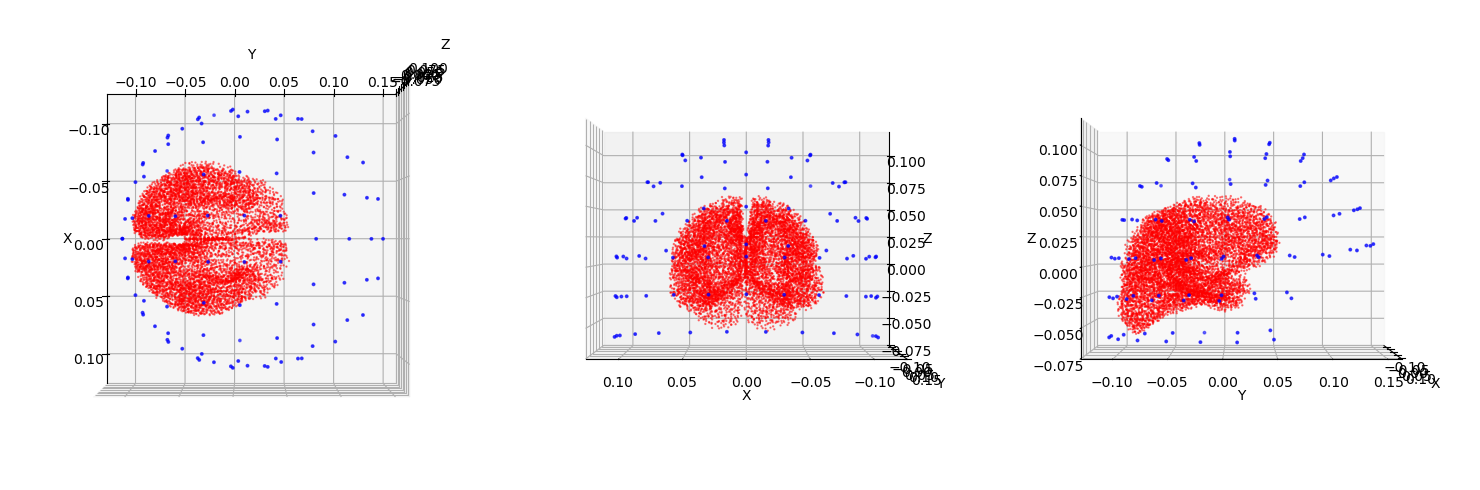

In [9]:
## plot source space
from mne.transforms import apply_trans

picks_meg = mne.pick_types(raw.info, meg=True)
meg_pos = np.array([raw.info['chs'][i]['loc'][:3] for i in picks_meg])
lh_pos = src[0]['rr'][src[0]['vertno']]  # LH
rh_pos = src[1]['rr'][src[1]['vertno']]  # RH
src_pos = np.vstack([lh_pos, rh_pos])
src_pos_meg = apply_trans(trans, src_pos)

fig = plt.figure(figsize=(15, 5))

# top view
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(meg_pos[:, 0], meg_pos[:, 1], meg_pos[:, 2], c='blue', s=3, alpha=0.3, label='MEG sensors')
ax1.scatter(src_pos_meg[:, 0], src_pos_meg[:, 1], src_pos_meg[:, 2], c='red', s=0.5, alpha=0.5, label='Sources')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.view_init(elev=90, azim=0)

# side view
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(meg_pos[:, 0], meg_pos[:, 1], meg_pos[:, 2], c='blue', s=3, alpha=0.3)
ax2.scatter(src_pos_meg[:, 0], src_pos_meg[:, 1], src_pos_meg[:, 2], c='red', s=0.5, alpha=0.5)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.view_init(elev=0, azim=90)

# front view
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(meg_pos[:, 0], meg_pos[:, 1], meg_pos[:, 2], c='blue', s=3, alpha=0.3)
ax3.scatter(src_pos_meg[:, 0], src_pos_meg[:, 1], src_pos_meg[:, 2], c='red', s=0.5, alpha=0.5)
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')
ax3.view_init(elev=0, azim=0)

plt.tight_layout()
plt.show()

blue=sensors; red=sources